<a href="https://colab.research.google.com/github/Sargam2808/DEEP_LEARNING_LAB/blob/main/DL_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 6 :

Implement a Sequence-to-Sequence (Seq2Seq) model for English-to-Spanish translation

In [ ]:
Installing and Importing Libraries

In [ ]:
!pip install nltk -q

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from nltk.translate.bleu_score import sentence_bleu
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


Uploading dataset

In [ ]:
uploaded = files.upload()


Saving spa.txt to spa.txt


Loading Dataset

In [ ]:
with open("spa.txt", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")

pairs = [line.split("\t") for line in lines]
pairs = [(en.lower(), sp.lower()) for en, sp in pairs]

pairs = pairs[:20000]
print("Using pairs:", len(pairs))


Using pairs: 20000


Dataset Information

In [ ]:
df = pd.DataFrame(pairs, columns=["English","Spanish"])
display(df.head())

en_lengths = [len(p[0].split()) for p in pairs]
es_lengths = [len(p[1].split()) for p in pairs]

print("Avg EN length:", np.mean(en_lengths))
print("Avg ES length:", np.mean(es_lengths))


,English,Spanish
0,pretend you're me.,hazte pasar por mí.
1,he loved the change.,a él le encantó el cambio.
2,we're both adults.,ambos somos adultos.
3,we got ready.,estábamos listos.
4,tom did warn mary.,tom sí que advirtió a mary.


Avg EN length: 3.3816
Avg ES length: 3.28115


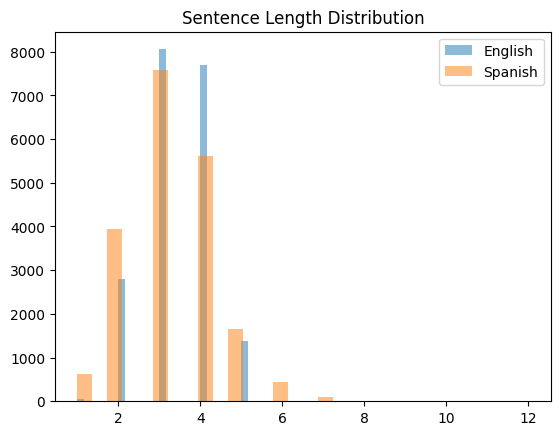

In [ ]:
plt.hist(en_lengths, bins=30, alpha=0.5, label="English")
plt.hist(es_lengths, bins=30, alpha=0.5, label="Spanish")
plt.legend()
plt.title("Sentence Length Distribution")
plt.show()


Splitting Data

In [ ]:
random.shuffle(pairs)

n = len(pairs)
train = pairs[:int(0.8*n)]
val = pairs[int(0.8*n):int(0.9*n)]
test = pairs[int(0.9*n):]


In [ ]:
Vocabulary

In [ ]:
def build_vocab(sentences):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())

    vocab = {"<pad>":0,"<sos>":1,"<eos>":2,"<unk>":3}
    for word in counter:
        vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab([x[0] for x in train])
tgt_vocab = build_vocab([x[1] for x in train])

INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)


DataLoader

In [ ]:
def encode(sentence, vocab):
    return [vocab.get(w, vocab["<unk>"]) for w in sentence.split()]

def add_tokens(seq):
    return [1] + seq + [2]

def collate_fn(batch):
    src_batch, tgt_batch = [], []

    for src, tgt in batch:
        src_seq = torch.tensor(add_tokens(encode(src, src_vocab)))
        tgt_seq = torch.tensor(add_tokens(encode(tgt, tgt_vocab)))
        src_batch.append(src_seq)
        tgt_batch.append(tgt_seq)

    src_batch = pad_sequence(src_batch, padding_value=0)
    tgt_batch = pad_sequence(tgt_batch, padding_value=0)

    return src_batch.to(device), tgt_batch.to(device)

train_loader = DataLoader(train, batch_size=64, shuffle=True, collate_fn=collate_fn)


Hyperparameters

In [ ]:
EMB_DIM = 128
HIDDEN_DIM = 256
EPOCHS = 10


Encoder

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


Decoder — No Attention

In [ ]:
class DecoderNoAttention(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        prediction = self.fc(output.squeeze(0))
        return prediction, hidden, cell


Decoder — Bahdanau

In [ ]:
class DecoderBahdanau(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim + hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, input, hidden, cell, encoder_outputs):

        input = input.unsqueeze(0)
        embedded = self.embedding(input)

        seq_len = encoder_outputs.shape[0]

        hidden_repeat = hidden.repeat(seq_len, 1, 1)

        energy = torch.tanh(self.W1(encoder_outputs) +
                            self.W2(hidden_repeat))

        attention = self.V(energy).squeeze(2)
        attention = torch.softmax(attention, dim=0)

        attention = attention.permute(1,0).unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1,0,2)

        context = torch.bmm(attention, encoder_outputs)
        context = context.permute(1,0,2)

        lstm_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.fc(
            torch.cat((output.squeeze(0), context.squeeze(0)), dim=1)
        )

        return prediction, hidden, cell


Training Function

In [ ]:
def train_model(encoder, decoder, attention=False):

    optimizer = optim.Adam(list(encoder.parameters()) +
                           list(decoder.parameters()))
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    losses = []

    for epoch in range(EPOCHS):
        encoder.train()
        decoder.train()
        epoch_loss = 0

        for src, tgt in train_loader:
            optimizer.zero_grad()

            encoder_outputs, hidden, cell = encoder(src)
            input = tgt[0]

            outputs = []

            for t in range(1, tgt.shape[0]):

                if attention:
                    prediction, hidden, cell = decoder(
                        input, hidden, cell, encoder_outputs)
                else:
                    prediction, hidden, cell = decoder(
                        input, hidden, cell)

                outputs.append(prediction)
                input = tgt[t]

            outputs = torch.stack(outputs)

            loss = criterion(outputs.reshape(-1, OUTPUT_DIM),
                             tgt[1:].reshape(-1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{EPOCHS} Loss: {epoch_loss:.3f}")

    return losses


Training Models

In [ ]:
# No Attention
enc1 = Encoder(INPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
dec1 = DecoderNoAttention(OUTPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)

loss_no_att = train_model(enc1, dec1, attention=False)

# Bahdanau Attention
enc2 = Encoder(INPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
dec2 = DecoderBahdanau(OUTPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)

loss_bah = train_model(enc2, dec2, attention=True)


Epoch 1/10 Loss: 1414.136
Epoch 2/10 Loss: 1120.886
Epoch 3/10 Loss: 942.933
Epoch 4/10 Loss: 800.966
Epoch 5/10 Loss: 684.136
Epoch 6/10 Loss: 585.402
Epoch 7/10 Loss: 500.300
Epoch 8/10 Loss: 425.259
Epoch 9/10 Loss: 360.147
Epoch 10/10 Loss: 304.525
Epoch 1/10 Loss: 1340.357
Epoch 2/10 Loss: 877.506
Epoch 3/10 Loss: 578.635
Epoch 4/10 Loss: 375.010
Epoch 5/10 Loss: 247.381
Epoch 6/10 Loss: 176.024
Epoch 7/10 Loss: 135.673
Epoch 8/10 Loss: 109.375
Epoch 9/10 Loss: 93.392
Epoch 10/10 Loss: 81.602


Decoder — Luong

In [ ]:
class DecoderLuong(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

        self.W = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, input, hidden, cell, encoder_outputs):

        input = input.unsqueeze(0)
        embedded = self.embedding(input)

        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))

        # encoder_outputs: [seq_len, batch, hidden]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # [batch, seq_len, hidden]

        hidden_transformed = self.W(hidden)
        hidden_transformed = hidden_transformed.permute(1, 2, 0)
        # [batch, hidden, 1]

        scores = torch.bmm(encoder_outputs, hidden_transformed)
        # [batch, seq_len, 1]

        attention = torch.softmax(scores, dim=1)

        context = torch.bmm(attention.transpose(1, 2),
                            encoder_outputs)
        # [batch, 1, hidden]

        context = context.permute(1, 0, 2)

        prediction = self.fc(
            torch.cat((output.squeeze(0),
                       context.squeeze(0)), dim=1)
        )

        return prediction, hidden, cell, attention


Training for luong

In [ ]:
def train_luong(encoder, decoder):

    optimizer = optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters())
    )

    criterion = nn.CrossEntropyLoss(ignore_index=0)
    losses = []

    for epoch in range(EPOCHS):

        encoder.train()
        decoder.train()

        epoch_loss = 0

        for src, tgt in train_loader:

            optimizer.zero_grad()

            encoder_outputs, hidden, cell = encoder(src)
            input = tgt[0]
            outputs = []

            for t in range(1, tgt.shape[0]):

                prediction, hidden, cell, attention = decoder(
                    input, hidden, cell, encoder_outputs
                )

                outputs.append(prediction)
                input = tgt[t]

            outputs = torch.stack(outputs)

            loss = criterion(
                outputs.reshape(-1, OUTPUT_DIM),
                tgt[1:].reshape(-1)
            )

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)
        print(f"Luong Epoch {epoch+1}/{EPOCHS} Loss: {epoch_loss:.3f}")

    return losses


In [ ]:
enc3 = Encoder(INPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
dec3 = DecoderLuong(OUTPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)

loss_luong = train_luong(enc3, dec3)



Luong Epoch 1/10 Loss: 1379.369
Luong Epoch 2/10 Loss: 989.021
Luong Epoch 3/10 Loss: 731.853
Luong Epoch 4/10 Loss: 533.047
Luong Epoch 5/10 Loss: 376.500
Luong Epoch 6/10 Loss: 264.810
Luong Epoch 7/10 Loss: 195.388
Luong Epoch 8/10 Loss: 151.673
Luong Epoch 9/10 Loss: 121.648
Luong Epoch 10/10 Loss: 101.867


Loss Comparision

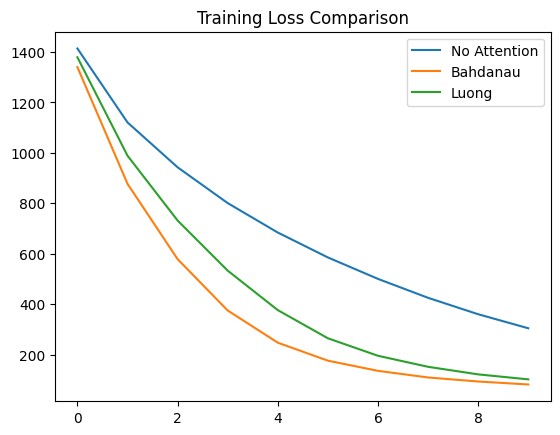

In [ ]:
plt.plot(loss_no_att, label="No Attention")
plt.plot(loss_bah, label="Bahdanau")
plt.plot(loss_luong, label="Luong")
plt.legend()
plt.title("Training Loss Comparison")
plt.show()


BLEU Evaluation

In [ ]:
def compute_bleu(encoder, decoder, attention=False, samples=300):

    total = 0

    for src, tgt in test[:samples]:

        tokens = ["<sos>"] + src.split() + ["<eos>"]
        src_idx = [src_vocab.get(t, src_vocab["<unk>"]) for t in tokens]
        src_tensor = torch.LongTensor(src_idx).unsqueeze(1).to(device)

        with torch.no_grad():
            encoder_outputs, hidden, cell = encoder(src_tensor)

        trg_idx = [tgt_vocab["<sos>"]]

        for _ in range(20):
            trg_tensor = torch.LongTensor([trg_idx[-1]]).to(device)

            with torch.no_grad():
                if attention:
                    out = decoder(trg_tensor, hidden, cell, encoder_outputs)
                    prediction, hidden, cell = out[0], out[1], out[2]
                else:
                    prediction, hidden, cell = decoder(
                        trg_tensor, hidden, cell
                    )

            pred = prediction.argmax(1).item()
            trg_idx.append(pred)

            if pred == tgt_vocab["<eos>"]:
                break

        prediction_words = [inv_tgt_vocab[i] for i in trg_idx[1:-1]]
        reference = tgt.split()

        total += sentence_bleu([reference], prediction_words)

    return total / samples


In [ ]:
inv_tgt_vocab = {v: k for k, v in tgt_vocab.items()}


Compute BLEU

In [ ]:
bleu_no = compute_bleu(enc1, dec1, attention=False)
bleu_bah = compute_bleu(enc2, dec2, attention=True)
bleu_luong = compute_bleu(enc3, dec3, attention=True)

print("BLEU No Attention:", bleu_no)
print("BLEU Bahdanau:", bleu_bah)
print("BLEU Luong:", bleu_luong)


BLEU No Attention: 0.01639755455018378
BLEU Bahdanau: 0.03163590191432757
BLEU Luong: 0.026753691755924673


BLEU Plot

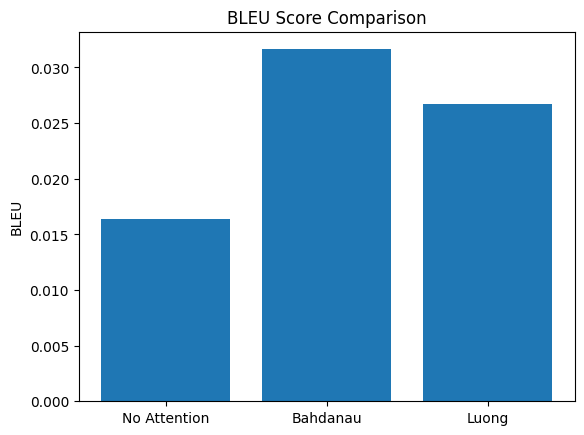

In [ ]:
models = ["No Attention","Bahdanau","Luong"]
scores = [bleu_no, bleu_bah, bleu_luong]

plt.bar(models, scores)
plt.title("BLEU Score Comparison")
plt.ylabel("BLEU")
plt.show()
